## Impoprty

In [ ]:
import zipfile
import io
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.metrics import confusion_matrix
import seaborn as sns

##  Wczytanie i przygotowanie prawdziwych danych z pliku ZIP

In [ ]:
zip_file_path = 'CEAS_08.csv.zip'

try:
    # Otworzenie archiwum ZIP
    with zipfile.ZipFile(zip_file_path, 'r') as z:
        # Pobranie nazwy pliku CSV ze środka archiwum
        csv_filename = [f for f in z.namelist() if f.endswith('.csv')][0]
        print(f"Znaleziono plik w archiwum: {csv_filename}")
        
        # Wczytanie pliku CSV pandas
        with z.open(csv_filename) as f:
            # pliki e-mail bywają "szumiące", więc trzeba wyrzuć zepsute linie
            df_raw = pd.read_csv(f, on_bad_lines='skip', encoding='utf-8', low_memory=False)

    print(f"Pomyślnie wczytano dane. Liczba wierszy: {df_raw.shape[0]}, Liczba kolumn: {df_raw.shape[1]}")
    print("\nDostępne kolumny w zbiorze:", df_raw.columns.tolist())

    # Sprawdzenie konfiguracji i ujednolicenie nazwy do dalszej części projektu:
    text_column = 'body' if 'body' in df_raw.columns else ('text' if 'text' in df_raw.columns else df_raw.columns[0])
    label_column = 'label' if 'label' in df_raw.columns else df_raw.columns[1]
    
    # Tworzenie czystego DataFrame zawierającego niezbędne informacje
    df = pd.DataFrame({
        'text': df_raw[text_column].astype(str),
        'label': df_raw[label_column]
    })
    
    # Czyszczenie brakujących danych (jeśli jakieś wiadomości były puste)
    df = df.dropna().reset_index(drop=True)
    
    # Skrócenie zbioru do 5000 próbek
    if len(df) > 5000:
        df = df.sample(n=5000, random_state=42).reset_index(drop=True)
        print(f"Ograniczono zbiór danych do {len(df)} losowych wierszy w celu optymalizacji czasu obliczeń.")

    print("\nRozkład klas po załadowaniu realnych danych:")
    print(df['label'].value_counts())

except FileNotFoundError:
    print(f"BŁĄD: Nie znaleziono pliku '{zip_file_path}'. Checklista:")
    print("1. Czy nazwa pliku się zgadza?")
    print("2. Czy plik .zip znajduje się w tym samym folderze co ten Jupyter Notebook?")
except Exception as e:
    print(f"Wystąpił nieoczekiwany błąd podczas wczytywania: {e}")

Znaleziono plik w archiwum: CEAS_08.csv
Pomyślnie wczytano dane. Liczba wierszy: 39154, Liczba kolumn: 7

Dostępne kolumny w zbiorze: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']
Ograniczono zbiór danych do 5000 losowych wierszy w celu optymalizacji czasu obliczeń.

Rozkład klas po załadowaniu realnych danych:
label
1    2761
0    2239
Name: count, dtype: int64


## Czyszczenie tekstu z e-maili

In [ ]:
def clean_text(text):
    text = text.lower()  # Zamiana na małe litery
    text = re.sub(r'\d+', '', text)  # Usuwanie cyfr (np. ID transakcji, numery)
    text = re.sub(r'[^\w\s]', '', text)  # Usuwanie znaków interpunkcyjnych
    return text

# Tworzenie nowej kolumny z oczyszczonym tekstem
df['cleaned_text'] = df['text'].apply(clean_text)

print("--- PODGLĄD DANYCH PO PREPROCESSINGU ---")
print("Oryginalny tekst (body):\n", df['text'].iloc[0][:120], "...\n")
print("Oczyszczony tekst:\n", df['cleaned_text'].iloc[0][:120], "...")

--- PODGLĄD DANYCH PO PREPROCESSINGU ---
Oryginalny tekst (body):
 Also, the sa-blacklist inclusion policy is at:

   http://www.stearns.org/sa-blacklist/README.policy

Jeff C.


 ...

Oczyszczony tekst:
 also the sablacklist inclusion policy is at

   httpwwwstearnsorgsablacklistreadmepolicy

jeff c


 ...


## Podział na zbiory i Wektoryzacja

In [ ]:
# mapowanie etykiet na format numeryczny (0 = ham, 1 = spam)
if df['label'].dtype == object:
    y = df['label'].str.lower().map({'ham': 0, 'spam': 1, '0': 0, '1': 1})
else:
    y = df['label'].astype(int)

# Usuwanie wartości NaN (Not a Number), które mogły powstać przy konwersji typu
valid_idx = y.notna()
X_text_raw = df['text'][valid_idx]
X_text_clean = df['cleaned_text'][valid_idx]
y = y[valid_idx].astype(int)

#  podział na zbiór treningowy i testowy (Stratify!)
X_train_raw, X_test_raw, X_train_clean, X_test_clean, y_train, y_test = train_test_split(
    X_text_raw, X_text_clean, y, test_size=0.3, random_state=42, stratify=y)

# Wektoryzacja danych surowych (Eksperyment 1)
vectorizer_raw = TfidfVectorizer(max_features=5000) # Ograniczenie cech dla szybkości obliczeń
X_train_tfidf_raw = vectorizer_raw.fit_transform(X_train_raw)
X_test_tfidf_raw = vectorizer_raw.transform(X_test_raw)

# Wektoryzacja danych oczyszczonych (Eksperyment 2)
vectorizer_clean = TfidfVectorizer(max_features=5000)
X_train_tfidf_clean = vectorizer_clean.fit_transform(X_train_clean)
X_test_tfidf_clean = vectorizer_clean.transform(X_test_clean)

print(f"Dane gotowe do eksperymentów. Rozmiar macierzy cech: {X_train_tfidf_raw.shape}")

Dane gotowe do eksperymentów. Rozmiar macierzy cech: (3500, 5000)


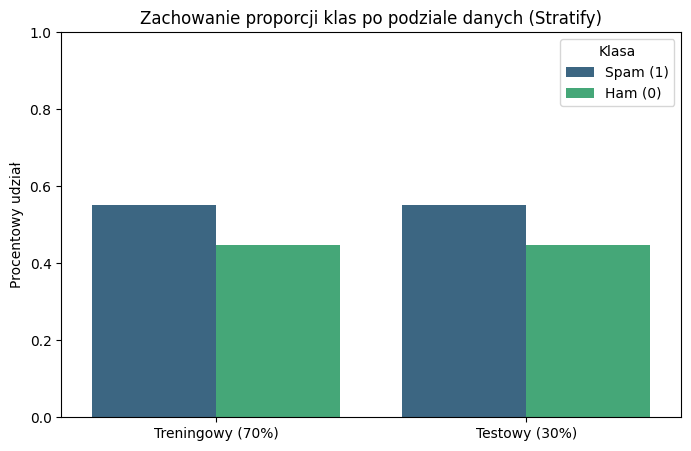

In [ ]:
# Obliczanie proporcji dla zbioru treningowego i testowego
train_counts = pd.Series(y_train).value_counts(normalize=True).to_frame()
train_counts.columns = ['Proporcja']
train_counts['Zbiór'] = 'Treningowy (70%)'

test_counts = pd.Series(y_test).value_counts(normalize=True).to_frame()
test_counts.columns = ['Proporcja']
test_counts['Zbiór'] = 'Testowy (30%)'

# Łączenie danych (indeks zawiera wartości 0 i 1)
df_vis = pd.concat([train_counts, test_counts])

# stworzenie kolumny 'Klasa" dla indexów
df_vis = df_vis.reset_index().rename(columns={df_vis.index.name if df_vis.index.name else 'index': 'Klasa'})
# df_vis.columns.values[0] = 'Klasa' # teoretycznie pandas może źle nazwać kolumnę, ale zakładam, że nie

# mapowanie wartości 0 i 1 na czytelne etykiety tekstowe
df_vis['Klasa'] = df_vis['Klasa'].map({0: 'Ham (0)', 1: 'Spam (1)'})

# rysowanie wykresu
plt.figure(figsize=(8, 5))
sns.barplot(data=df_vis, x='Zbiór', y='Proporcja', hue='Klasa', palette='viridis')
plt.title('Zachowanie proporcji klas po podziale danych (Stratify)')
plt.ylabel('Procentowy udział')
plt.xlabel('')
plt.ylim(0, 1) # Skala od 0 do 100%
plt.show()

## EKSPERYMENT 1 oraz EKSPERYMENT 2 (Uczenie modeli)

EKSPERYMENT 1
Kod trenuje dwa różne modele na tych samych, surowych (nieoczyszczonych) tekstach.
Następnie oba modele przewidują etykiety dla danych testowych, a funkcja classification_report generuje raport z wynikami, co pozwala ocenić, który algorytm radzi sobie lepiej z tekstem.

EKSPERYMENT 2
wykonanie tego samego co w 1 ekseprymencie, ale na oczyszczonych danych w celu porównania co jest lepsze :D

In [ ]:
print("EKSPERYMENT 1: Porównanie Algorytmów - Naive Bayes vs Random Forest")

# Model A: Naive Bayes (Dane Surowe)
model_nb = MultinomialNB()
model_nb.fit(X_train_tfidf_raw, y_train)
preds_nb = model_nb.predict(X_test_tfidf_raw)

# Model B: Random Forest (Dane Surowe)
# n_estimators=50 i max_depth=20 zapewnią błyskawiczne działanie na zajęciach
model_rf = RandomForestClassifier(n_estimators=50, max_depth=20, random_state=42, n_jobs=-1)
model_rf.fit(X_train_tfidf_raw, y_train)
preds_rf = model_rf.predict(X_test_tfidf_raw)

print("Naive Bayes - wyniki")
print(classification_report(y_test, preds_nb, target_names=['Bezpieczny (Ham)', 'Zagrożenie (Spam)']))

print("Random Forest - wyniki")
print(classification_report(y_test, preds_rf, target_names=['Bezpieczny (Ham)', 'Zagrożenie (Spam)']))

print("==================================================================\n")
print("EKSPERYMENT 2: Wpływ Preprocessingu Tekstu (Naive Bayes)")

# Model C: Naive Bayes (Dane Oczyszczone)
model_nb_clean = MultinomialNB()
model_nb_clean.fit(X_train_tfidf_clean, y_train)
preds_nb_clean = model_nb_clean.predict(X_test_tfidf_clean)

print("Naive Bayes (oczyszczone dane) - wyniki")
print(classification_report(y_test, preds_nb_clean, target_names=['Bezpieczny (Ham)', 'Zagrożenie (Spam)']))

EKSPERYMENT 1: Porównanie Algorytmów - Naive Bayes vs Random Forest
Naive Bayes - wyniki
                   precision    recall  f1-score   support

 Bezpieczny (Ham)       0.95      0.99      0.97       672
Zagrożenie (Spam)       0.99      0.96      0.97       828

         accuracy                           0.97      1500
        macro avg       0.97      0.97      0.97      1500
     weighted avg       0.97      0.97      0.97      1500

Random Forest - wyniki
                   precision    recall  f1-score   support

 Bezpieczny (Ham)       0.97      0.97      0.97       672
Zagrożenie (Spam)       0.97      0.98      0.98       828

         accuracy                           0.97      1500
        macro avg       0.97      0.97      0.97      1500
     weighted avg       0.97      0.97      0.97      1500


EKSPERYMENT 2: Wpływ Preprocessingu Tekstu (Naive Bayes)
Naive Bayes (oczyszczone dane) - wyniki
                   precision    recall  f1-score   support

 Bezpieczny (Ham

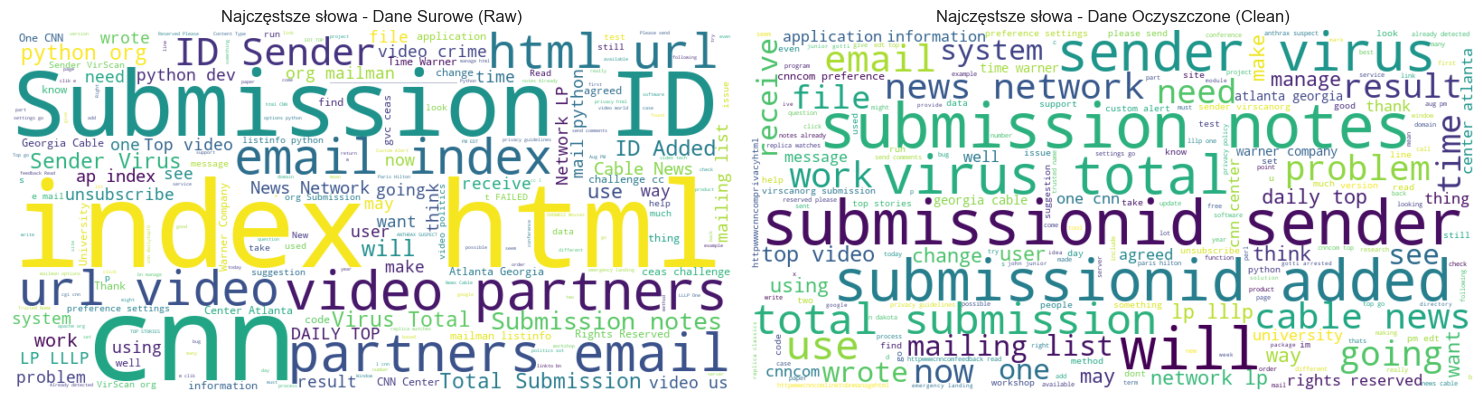

In [ ]:
!pip install wordcloud
from wordcloud import WordCloud

# Połączenie tekstów w jeden ciąg dla wersji surowej i oczyszczonej
raw_text_space = " ".join(X_train_raw.astype(str))
clean_text_space = " ".join(X_train_clean.astype(str))

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Chmura dla danych surowych
wordcloud_raw = WordCloud(width=800, height=400, background_color='white').generate(raw_text_space)
axes[0].imshow(wordcloud_raw, interpolation='bilinear')
axes[0].set_title('Najczęstsze słowa - Dane Surowe (Raw)')
axes[0].axis('off')

# Chmura dla danych oczyszczonych
wordcloud_clean = WordCloud(width=800, height=400, background_color='white').generate(clean_text_space)
axes[1].imshow(wordcloud_clean, interpolation='bilinear')
axes[1].set_title('Najczęstsze słowa - Dane Oczyszczone (Clean)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Wizualizacja

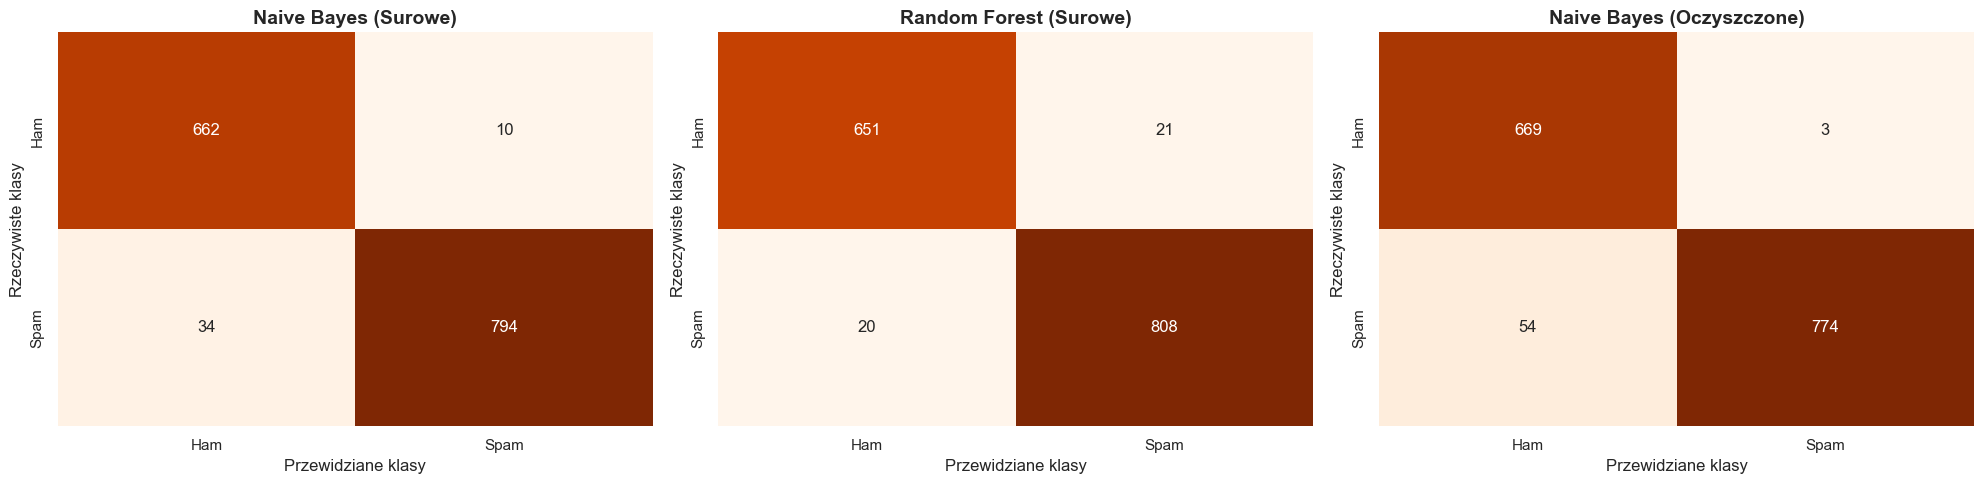

In [ ]:
# wszystkie wygenerowane wykresy będą wyświetlane pod komórką z kodem
%matplotlib inline 
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

models_plots = [
    ("Naive Bayes (Surowe)", preds_nb),
    ("Random Forest (Surowe)", preds_rf),
    ("Naive Bayes (Oczyszczone)", preds_nb_clean)
]

for ax, (title, preds) in zip(axes, models_plots):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax, cbar=False,
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Przewidziane klasy', fontsize=12)
    ax.set_ylabel('Rzeczywiste klasy', fontsize=12)

plt.tight_layout()
plt.show()

## Analiza Statystyczna

statystyczne porównanie dwóch modeli uczenia maszynowego, aby sprawdzić, czy jeden z nich jest lepszy od drugiego, czy też różnica w ich wynikach to zwykły przypadek. Wykorzystuje do tego test McNemara.

In [ ]:
def oblicz_mcnemar(preds_a, preds_b, y_true, nazwa_a, nazwa_b):
    a_correct = (preds_a == y_true)
    b_correct = (preds_b == y_true)
    
    # Tworzenie macierzy błędów parzystych 2x2
    table = [
        [np.sum(a_correct & b_correct),  np.sum(a_correct & ~b_correct)],
        [np.sum(~a_correct & b_correct), np.sum(~a_correct & ~b_correct)]
    ]
    
    result = mcnemar(table, exact=True)
    
    print(f"Porównanie: {nazwa_a} VS {nazwa_b}")
    print(f"p-value: {result.pvalue:.5f}")
    
    if result.pvalue < 0.05:
        print("Różnica w dokładności modeli JEST istotna statystycznie (odrzucamy hipotezę).")
    else:
        print("Różnica NIE JEST istotna statystycznie (brak podstaw do odrzucenia hipotezę).")
    print("-" * 65)

# 1. Statystyczne porównanie modeli (Eksperyment 1)
oblicz_mcnemar(preds_nb, preds_rf, y_test, "Naive Bayes (surowe)", "Random Forest (surowe)")

# 2. Statystyczne badanie wpływu preprocessingu (Eksperyment 2)
oblicz_mcnemar(preds_nb, preds_nb_clean, y_test, "Naive Bayes (Surowe)", "Naive Bayes (oczyszczone)")

# TODO - balanced accuracy wyświetlić dla 4 przypadków

Porównanie: Naive Bayes (surowe) VS Random Forest (surowe)
p-value: 0.79137
Różnica NIE JEST istotna statystycznie (brak podstaw do odrzucenia hipotezę).
-----------------------------------------------------------------
Porównanie: Naive Bayes (Surowe) VS Naive Bayes (oczyszczone)
p-value: 0.02945
Różnica w dokładności modeli JEST istotna statystycznie (odrzucamy hipotezę).
-----------------------------------------------------------------
